# Collective Posterior Samplers

This notebook demonstrates the main sampling options implemented for the collective posterior.

It defaults to `GLU`, but the setup cell is written so you can switch to another simulator and reuse the same workflow.

Sampling methods covered here:
- Rejection sampling
- MCMC from top candidates
- SIR with jitter
- Adaptive tempered SIR with refinement


## Setup

In [1]:
from pathlib import Path
import math
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

from collective_posterior import CollectivePosterior
from evo_sim import EVO_SIM_wrapper, evo_sim
from inference_utils import get_prior
from simulators import GLU, GLU_wrapper, SLCP, SLCP_wrapper, WF, WF_wrapper

torch.set_grad_enabled(False)
torch.manual_seed(17)
sns.set_theme(style="whitegrid")

repo_root = Path.cwd()
assert (repo_root / "collective_posterior.py").exists(), "Run this notebook from Posterior/collective_posterior"

SIM_NAME = "EVO_SIM"  # Change to one of: GLU, SLCP, WF, EVO_SIM
NUM_REPS = 10
N_SAMPLES = 250
N_EVAL = 2_000
PLOT_DIMS = 6

DEFAULT_POSTERIORS = {
    "GLU": repo_root / "GLU" / "posteriors" / "posterior_GLU_100000_20.pkl",
    "SLCP": repo_root / "SLCP" / "posteriors" / "posterior_SLCP_100000_20.pkl",
    "WF": repo_root / "WF" / "posteriors" / "posterior_WF_30000_20.pkl",
    "EVO_SIM": repo_root / "EVO_SIM" / "posterior_EVO_SIM_30000_20.pkl",
}

SIMULATORS = {
    "GLU": GLU,
    "SLCP": SLCP,
    "WF": WF,
    "EVO_SIM": evo_sim,
}

WRAPPERS = {
    "GLU": GLU_wrapper,
    "SLCP": SLCP_wrapper,
    "WF": WF_wrapper,
    "EVO_SIM": EVO_SIM_wrapper,
}

EPSILONS = {
    "GLU": -10000,
    "SLCP": -10,
    "WF": -10,
    "EVO_SIM": -10,
}

posterior_path = DEFAULT_POSTERIORS[SIM_NAME]
assert posterior_path.exists(), f"Missing posterior file: {posterior_path}"

prior = get_prior(SIM_NAME)
simulator = SIMULATORS[SIM_NAME]
wrapper = WRAPPERS[SIM_NAME]
epsilon = EPSILONS[SIM_NAME]

with open(posterior_path, "rb") as handle:
    amortized_posterior = pickle.load(handle)

theta_true = prior.sample()
Xs = wrapper(reps=NUM_REPS, parameters=theta_true)

def build_cp():
    return CollectivePosterior(
        prior=prior,
        Xs=Xs,
        amortized_posterior=amortized_posterior,
        epsilon=epsilon,
        n_eval=N_EVAL,
    )

def get_prior_bounds(prior):
    if hasattr(prior, "base_dist") and hasattr(prior.base_dist, "low"):
        return prior.base_dist.low.detach().cpu(), prior.base_dist.high.detach().cpu()
    if hasattr(prior, "low") and hasattr(prior, "high"):
        return prior.low.detach().cpu(), prior.high.detach().cpu()
    try:
        return prior.support.base_constraint.lower_bound.detach().cpu(), prior.support.base_constraint.upper_bound.detach().cpu()
    except Exception:
        return None, None

def summarize_samples(samples, label, theta=None, max_dims=PLOT_DIMS):
    samples = torch.as_tensor(samples).detach().cpu()
    theta = None if theta is None else torch.as_tensor(theta).detach().cpu()
    dims = min(samples.shape[1], max_dims)
    prior_low, prior_high = get_prior_bounds(prior)
    colnames = [f"theta_{i}" for i in range(dims)]
    df = pd.DataFrame(samples[:, :dims].numpy(), columns=colnames)
    display(df.describe().T[["mean", "std", "min", "max"]])

    fig, axes = plt.subplots(1, dims, figsize=(4 * dims, 3.5))
    if dims == 1:
        axes = [axes]
    for i in range(dims):
        sns.histplot(df[colnames[i]], ax=axes[i], kde=True, color="tomato")
        if theta is not None:
            axes[i].axvline(float(theta[i]), color="black", linestyle="--", linewidth=2)
        if prior_low is not None and prior_high is not None:
            axes[i].set_xlim(float(prior_low[i]), float(prior_high[i]))
        axes[i].set_title(f"{label}: dim {i}")
    plt.tight_layout()
    plt.show()

print("Simulator:", SIM_NAME)
print("Posterior:", posterior_path.relative_to(repo_root))
print("theta dimension:", theta_true.shape[0])
print("replicate shape:", tuple(Xs.shape))
print("epsilon:", epsilon)

Simulator: EVO_SIM
Posterior: EVO_SIM/posterior_EVO_SIM_30000_20.pkl
theta dimension: 6
replicate shape: (10, 30)
epsilon: -10


True theta (first dimensions):


,true_theta
theta_0,-2.131517
theta_1,-1.929781
theta_2,-1.339583
theta_3,-7.504546
theta_4,-7.882716
theta_5,-5.802416


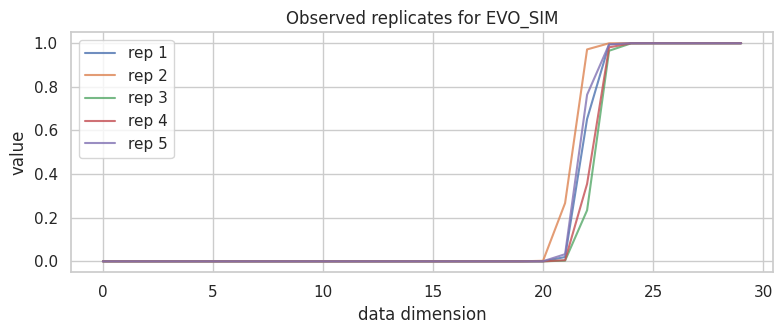

In [2]:
print("True theta (first dimensions):")
display(pd.DataFrame({"true_theta": theta_true.detach().cpu().numpy()[:min(len(theta_true), PLOT_DIMS)]}, index=[f"theta_{i}" for i in range(min(len(theta_true), PLOT_DIMS))]))

fig, ax = plt.subplots(figsize=(8, 3.5))
for i in range(min(NUM_REPS, 5)):
    ax.plot(Xs[i].detach().cpu().numpy(), alpha=0.8, label=f"rep {i+1}")
ax.set_title(f"Observed replicates for {SIM_NAME}")
ax.set_xlabel("data dimension")
ax.set_ylabel("value")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## Rejection Sampling

This uses prior samples and accepts them according to the collective posterior score. It is simple and exact up to the usual rejection-sampling efficiency issues, but it can become slow in higher dimensions or for sharply concentrated posteriors.

In this implementation, `log_C` is estimated first because the collective posterior `log_prob` requires it.

Estimated log_C: 57.08382034301758


Rejection Sampling: 100%|██████████| 250/250 [00:14<00:00, 17.76it/s]

Rejection sample shape: (250, 6)


,mean,std,min,max
theta_0,-2.445178,0.228830,-2.924058,-1.821010
theta_1,-2.207996,0.456897,-2.988582,-1.102956
theta_2,-1.341548,0.024014,-1.652638,-1.305113
theta_3,-6.629982,0.466297,-7.855611,-5.477875
theta_4,-7.083164,0.521984,-7.929951,-4.000000
theta_5,-5.751409,0.219309,-6.282398,-4.449628


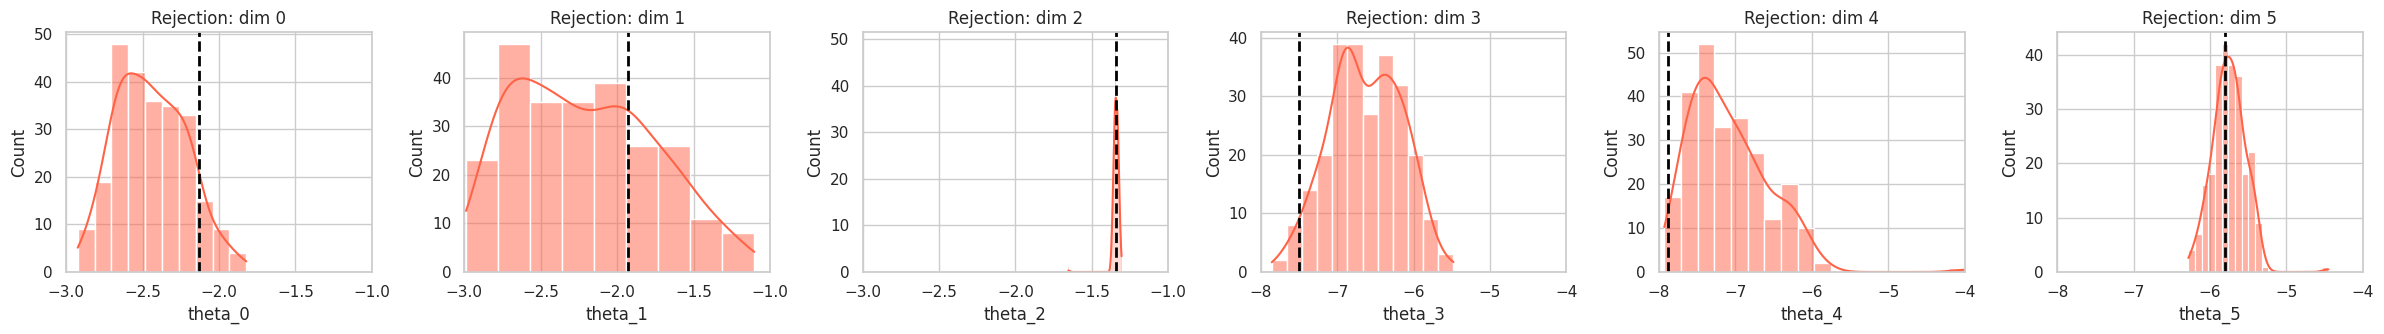

In [3]:
cp_rejection = build_cp()
log_C_rejection = cp_rejection.get_log_C(n_reps=1, S=0.05)
print("Estimated log_C:", float(log_C_rejection))

samples_rejection = cp_rejection.sample(
    n_samples=N_SAMPLES,
    method="rejection",
    jump=10_000,
    m=1.5,
    num_workers=10,
)

print("Rejection sample shape:", tuple(samples_rejection.shape))
summarize_samples(samples_rejection, "Rejection", theta_true)

## MCMC From Top Candidates

This path first uses `get_log_C()` to generate and rank a pool of promising prior samples, then starts independent Metropolis-Hastings chains from the top candidates. It is often a good compromise when pure rejection sampling becomes inefficient.

The important parameters here are:
- `take_sn`: how many top candidates to seed chains from
- `step_size`: proposal scale for the random walk

Estimated log_C: 49.89213180541992
Stored candidate pool: 100
take_sn: 20


MCMC from top 20 candidates: 100%|██████████| 1000/1000 [00:10<00:00, 96.08it/s]

MCMC sample shape: (1000, 6)


,mean,std,min,max
theta_0,-2.192307,0.506149,-3.007449,-1.186252
theta_1,-2.365456,0.504760,-3.044982,-1.155979
theta_2,-1.338809,0.029850,-1.424753,-1.218838
theta_3,-6.661142,0.640661,-7.885742,-5.537040
theta_4,-6.593965,0.683533,-7.953204,-5.348308
theta_5,-6.327795,0.596333,-7.427233,-5.162085


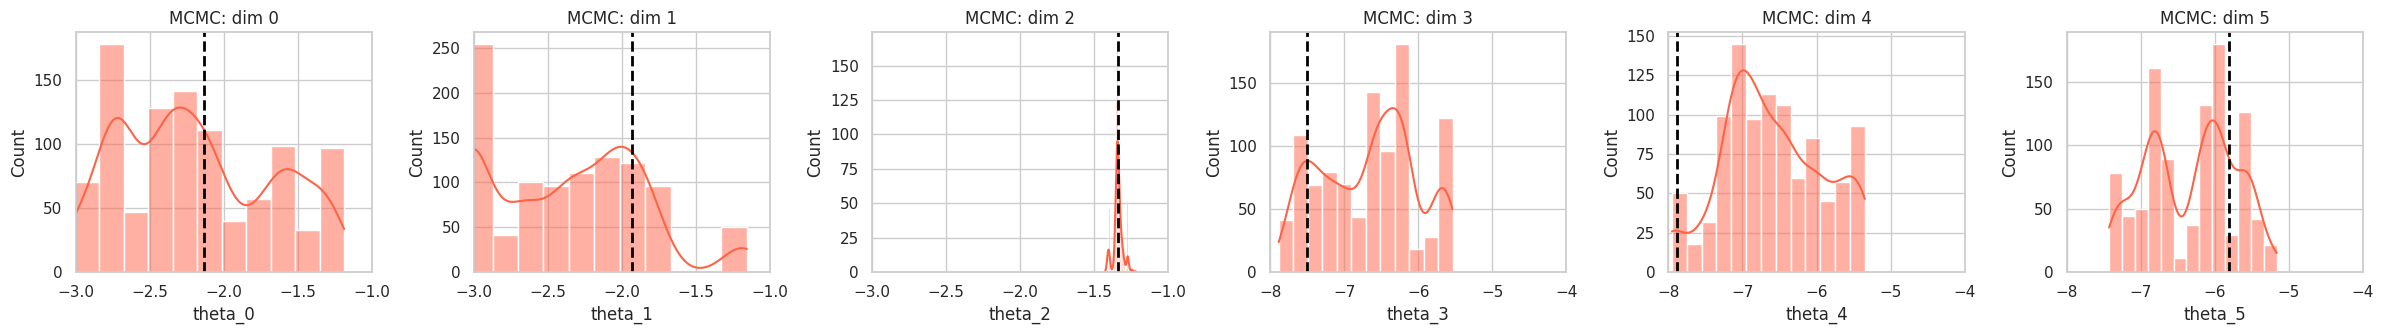

In [4]:
cp_mcmc = build_cp()
log_C_mcmc = cp_mcmc.get_log_C(n_reps=1, S=0.05)
take_sn = min(20, len(cp_mcmc.samples))
print("Estimated log_C:", float(log_C_mcmc))
print("Stored candidate pool:", len(cp_mcmc.samples))
print("take_sn:", take_sn)

samples_mcmc = cp_mcmc.sample(
    n_samples=1000,
    method="mcmc",
    take_sn=take_sn,
    step_size=0.05,
)

print("MCMC sample shape:", tuple(samples_mcmc.shape))
summarize_samples(samples_mcmc, "MCMC", theta_true)

## SIR With Jitter

This is a gradient-free importance-resampling method. It draws a pool from the prior, scores the pool under the robust collective posterior, resamples high-weight points, and then adds Gaussian jitter to smooth the sample set.

This is often the easiest method to use in practice because it does not require `log_C` and tends to work robustly with reasonable hyperparameters.

Evaluating 100000 samples: 100%|██████████| 10/10 [00:00<00:00, 10.96it/s]

Sampled 250 points with jitter and reflection. ESS = 12.397204399108887
SIR+jitter sample shape: (250, 6)


,mean,std,min,max
theta_0,-2.428928,0.072590,-2.682708,-2.275784
theta_1,-2.055456,0.426416,-2.982463,-1.010398
theta_2,-1.343433,0.010140,-1.370429,-1.309489
theta_3,-6.582567,0.308764,-7.350571,-5.818359
theta_4,-7.265334,0.633648,-7.998478,-4.812972
theta_5,-5.880619,0.162504,-6.338607,-5.409128


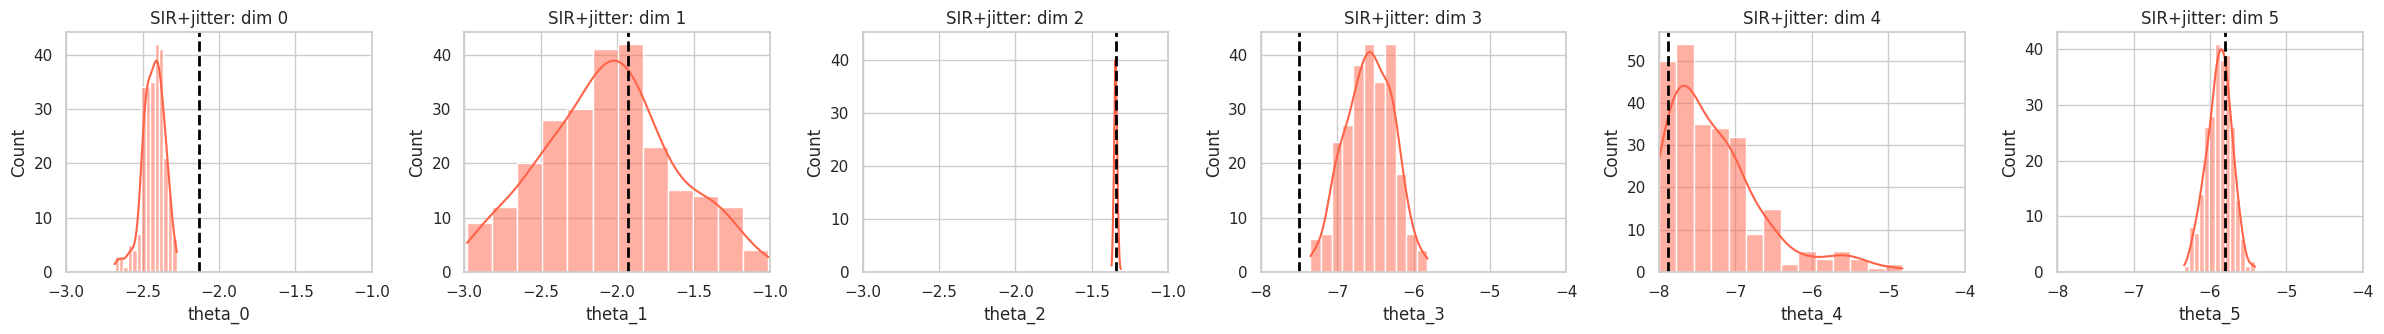

In [5]:
cp_sir = build_cp()

samples_sir = cp_sir.sample_via_sir_jitter(
    n_draws=100_000,
    n_final=N_SAMPLES
)

print("SIR+jitter sample shape:", tuple(samples_sir.shape))
summarize_samples(samples_sir, "SIR+jitter", theta_true)

## Adaptive Tempered SIR With Refinement

This is the recommended default sampler in the notebook. It keeps the same overall idea as SIR, but reduces manual tuning:
- it chooses the tempering automatically from a minimum effective sample size target
- it uses stratified resampling for lower-variance selection
- it adds a Gaussian refinement step
- it re-scores the refined proposals under the untempered collective target and keeps the best ones

High-level flow:
1. draw a pool of candidates from the prior
2. score them under the collective posterior target
3. flatten the importance weights only if their ESS is too small
4. resample promising points
5. jitter them slightly
6. score the refined proposals under the true untempered target and keep the best ones

`ess_min_frac` controls the minimum effective sample size target as a fraction of `n_draws`. With the current defaults, `n_draws=100000` and `ess_min_frac=0.001`, so the target ESS is `100`. If the raw untempered weights already have ESS at least `100`, the method keeps temperature `1.0` and does not flatten them further. In other words, this is a minimum ESS target, not an exact ESS target.

`oversample` controls how many candidates are kept during refinement before pruning back to the final sample count. With the current default `oversample=2.0`, the method refines `2 * n_final` candidates and then keeps the best `n_final`.

In practice this tends to be a better balance of stability, fidelity to the collective posterior, and speed than either pure rejection sampling or hand-tuned SIR temperatures.


Adaptive SIR attempt 1/3: evaluating 100000 samples: 100%|██████████| 10/10 [00:00<00:00, 16.82it/s]
Adaptive SIR attempt 1/3: rescoring 500 refined samples: 100%|██████████| 10/10 [00:00<00:00, 35.12it/s]

Adaptive SIR attempt 1/3 drew 100000 proposals, refined 500, returned 250 samples. Temperature = 5.6536, ESS = 100.00.
Adaptive SIR sample shape: (250, 6)


,attempt,attempts_used,temperature,ess,raw_target_ess,target_ess,proposal_pool,refinement_pool,jitter_scale,reached_target
0,1,1,5.653625,100.000214,100.0,100.0,100000,500,0.15,True


,mean,std,min,max
theta_0,-2.353785,0.207761,-2.850764,-1.800093
theta_1,-2.366639,0.436753,-2.993772,-1.206810
theta_2,-1.338009,0.015908,-1.372703,-1.297359
theta_3,-6.634058,0.478538,-7.708741,-5.520501
theta_4,-7.031543,0.586356,-7.887514,-5.645406
theta_5,-5.855021,0.270335,-6.468619,-5.212965


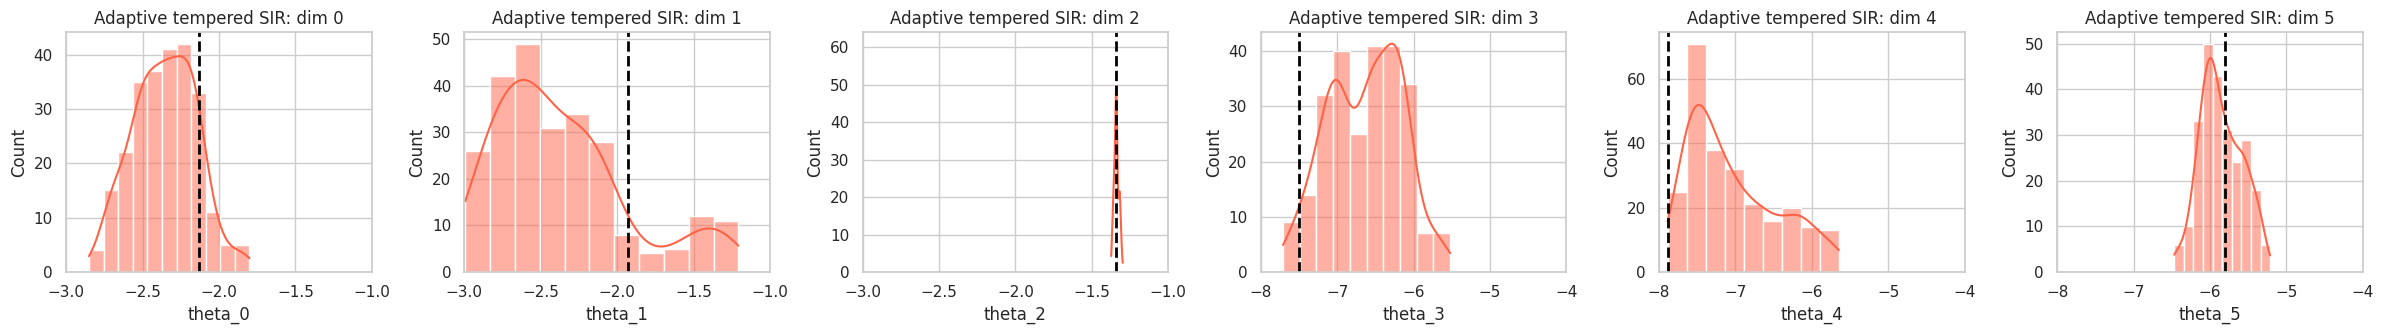

In [6]:
cp_adaptive = build_cp()

samples_adaptive = cp_adaptive.adaptive_sir(
    n_draws=100_000,
    n_final=N_SAMPLES,
    ess_min_frac=1e-3,
    oversample=2.0,
    jitter_scale=0.15,
)
adaptive_diag = cp_adaptive.last_adaptive_sir_diagnostics

print("Adaptive SIR sample shape:", tuple(samples_adaptive.shape))
if adaptive_diag is not None:
    display(pd.DataFrame([adaptive_diag]))
summarize_samples(samples_adaptive, "Adaptive tempered SIR", theta_true)


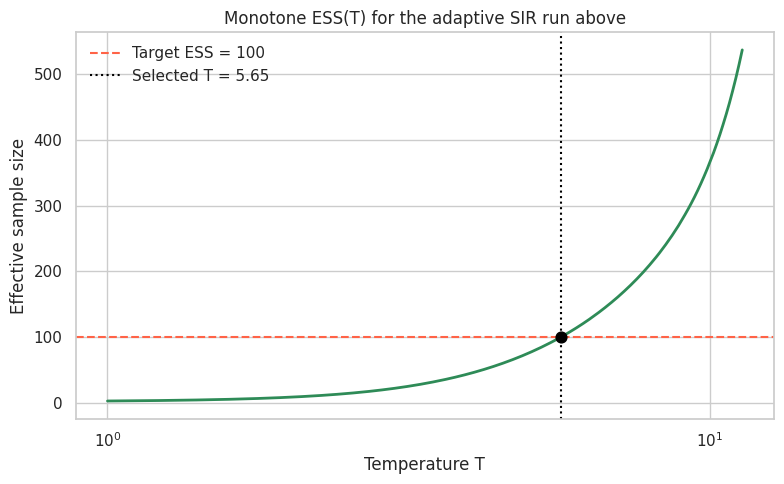

Selected temperature: 5.65363
Target ESS: 100.00
Achieved ESS at selected T: 100.00


In [7]:
log_weights = cp_adaptive.last_adaptive_sir_log_weights
if log_weights is None or adaptive_diag is None:
    raise RuntimeError('Run the adaptive SIR cell above first so the ESS(T) diagnostic can reuse that run.')

selected_temperature = float(adaptive_diag['temperature'])
target_ess = float(adaptive_diag['target_ess'])
selected_ess, _ = cp_adaptive._ess_and_weights(log_weights / selected_temperature)

t_max = max(selected_temperature * 2.0, 1.0)
if t_max == 1.0:
    temperatures = torch.tensor([1.0])
else:
    temperatures = torch.logspace(0.0, math.log10(t_max), steps=200)

ess_values = torch.tensor([cp_adaptive._ess_and_weights(log_weights / float(T))[0] for T in temperatures])

fig, ax = plt.subplots(1, 1, figsize=(8, 5), tight_layout=True)
ax.plot(temperatures.numpy(), ess_values.numpy(), color='seagreen', lw=2)
ax.axhline(target_ess, color='tomato', ls='--', lw=1.5, label=f'Target ESS = {target_ess:.0f}')
ax.axvline(selected_temperature, color='black', ls=':', lw=1.5, label=f'Selected T = {selected_temperature:.3g}')
ax.scatter([selected_temperature], [float(selected_ess)], color='black', s=60, zorder=5)
ax.set_xscale('log')
ax.set_xlabel('Temperature T')
ax.set_ylabel('Effective sample size')
ax.set_title('Monotone ESS(T) for the adaptive SIR run above')
ax.legend(frameon=False)
plt.show()

print(f'Selected temperature: {selected_temperature:.6g}')
print(f'Target ESS: {target_ess:.2f}')
print(f'Achieved ESS at selected T: {float(selected_ess):.2f}')


## Stability Over Repeated Runs

This section runs both `SIR+jitter` and `Adaptive SIR` 10 times with the same collective posterior. For each run, it computes the sample interquartile range (IQR) and the sample mean for each parameter dimension. We then compare two things: the variance of the IQR across runs, which measures stability, and the absolute error of the sample mean relative to the true parameter, which measures accuracy.


Evaluating 100000 samples:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating 100000 samples: 100%|██████████| 10/10 [00:00<00:00, 13.99it/s]


Sampled 250 points with jitter and reflection. ESS = 32.43267822265625


Adaptive SIR attempt 1/3: evaluating 100000 samples: 100%|██████████| 10/10 [00:00<00:00, 20.31it/s]
Adaptive SIR attempt 1/3: rescoring 500 refined samples: 100%|██████████| 10/10 [00:00<00:00, 34.97it/s]


Adaptive SIR attempt 1/3 drew 100000 proposals, refined 500, returned 250 samples. Temperature = 6.2604, ESS = 100.00.


...

Sampled 250 points with jitter and reflection. ESS = 18.82438087463379


Adaptive SIR attempt 1/3: evaluating 100000 samples: 100%|██████████| 10/10 [00:00<00:00, 22.57it/s]
Adaptive SIR attempt 1/3: rescoring 500 refined samples: 100%|██████████| 10/10 [00:00<00:00, 35.22it/s]

Adaptive SIR attempt 1/3 drew 100000 proposals, refined 500, returned 250 samples. Temperature = 6.3617, ESS = 100.00.


,sir_iqr_mean,sir_iqr_var,sir_mean_abs_error,adaptive_iqr_mean,adaptive_iqr_var,adaptive_mean_abs_error
theta_0,0.245752,0.005051,0.354824,0.384909,0.002063,0.286420
theta_1,0.712040,0.029121,0.223663,0.732625,0.005029,0.283661
theta_2,0.020198,0.000025,0.002524,0.023734,0.000004,0.002074
theta_3,0.597372,0.050402,0.908208,0.743845,0.002259,0.791527
theta_4,0.711115,0.042990,0.691454,0.708660,0.008535,0.766540
theta_5,0.283085,0.003816,0.057128,0.368201,0.000835,0.032923


,sir_mean_iqr_variance,sir_mean_abs_error,adaptive_mean_iqr_variance,adaptive_mean_abs_error
0,0.021901,0.372967,0.003121,0.360524


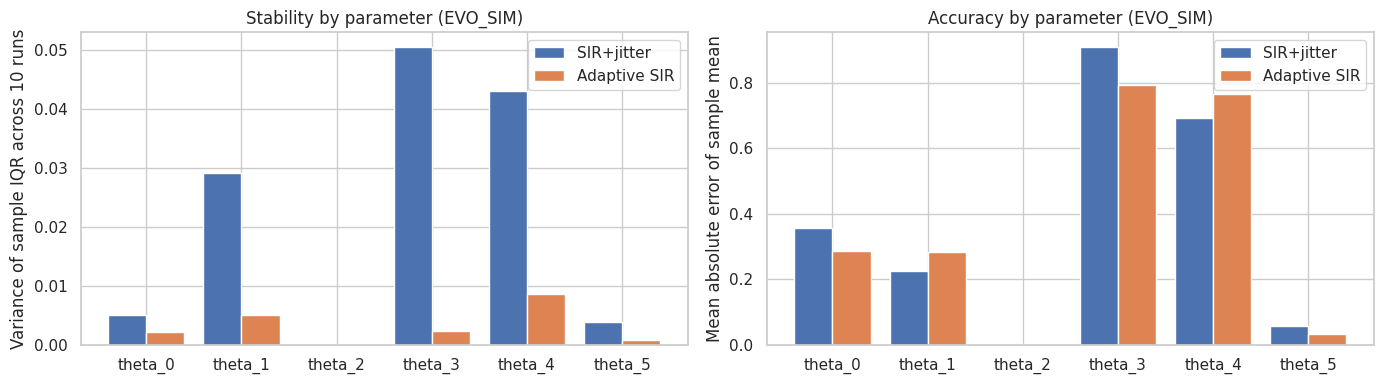

In [8]:
def sample_iqr(samples):
    samples = torch.as_tensor(samples)
    q75 = torch.quantile(samples, 0.75, dim=0)
    q25 = torch.quantile(samples, 0.25, dim=0)
    return q75 - q25


def run_sampler_stability(n_runs=10, sir_seed_offset=0, adaptive_seed_offset=10_000):
    sir_iqrs = []
    sir_means = []
    adaptive_iqrs = []
    adaptive_means = []

    for run_idx in range(n_runs):
        torch.manual_seed(1234 + sir_seed_offset + run_idx)
        cp_sir_repeat = build_cp()
        sir_samples_repeat = cp_sir_repeat.sample_via_sir_jitter(
            n_draws=100_000,
            n_final=N_SAMPLES,
        )
        sir_iqrs.append(sample_iqr(sir_samples_repeat))
        sir_means.append(torch.as_tensor(sir_samples_repeat).mean(0))

        torch.manual_seed(1234 + adaptive_seed_offset + run_idx)
        cp_adaptive_repeat = build_cp()
        adaptive_samples_repeat = cp_adaptive_repeat.adaptive_sir(
            n_draws=100_000,
            n_final=N_SAMPLES,
            ess_min_frac=1e-3,
            oversample=2.0,
            jitter_scale=0.5,
        )
        adaptive_iqrs.append(sample_iqr(adaptive_samples_repeat))
        adaptive_means.append(torch.as_tensor(adaptive_samples_repeat).mean(0))

    sir_iqrs = torch.stack(sir_iqrs)
    sir_means = torch.stack(sir_means)
    adaptive_iqrs = torch.stack(adaptive_iqrs)
    adaptive_means = torch.stack(adaptive_means)

    theta_target = theta_true.detach().cpu()
    sir_mean_abs_error = torch.abs(sir_means.detach().cpu() - theta_target)
    adaptive_mean_abs_error = torch.abs(adaptive_means.detach().cpu() - theta_target)

    return {
        "sir_iqrs": sir_iqrs,
        "sir_means": sir_means,
        "adaptive_iqrs": adaptive_iqrs,
        "adaptive_means": adaptive_means,
        "sir_iqr_var": torch.var(sir_iqrs, dim=0, unbiased=False),
        "adaptive_iqr_var": torch.var(adaptive_iqrs, dim=0, unbiased=False),
        "sir_mean_abs_error": sir_mean_abs_error,
        "adaptive_mean_abs_error": adaptive_mean_abs_error,
    }


stability = run_sampler_stability(n_runs=10)
dims = min(PLOT_DIMS, theta_true.shape[0])
theta_labels = [f"theta_{i}" for i in range(dims)]

stability_table = pd.DataFrame({
    "sir_iqr_mean": stability["sir_iqrs"].mean(0).detach().cpu().numpy()[:dims],
    "sir_iqr_var": stability["sir_iqr_var"].detach().cpu().numpy()[:dims],
    "sir_mean_abs_error": stability["sir_mean_abs_error"].mean(0).detach().cpu().numpy()[:dims],
    "adaptive_iqr_mean": stability["adaptive_iqrs"].mean(0).detach().cpu().numpy()[:dims],
    "adaptive_iqr_var": stability["adaptive_iqr_var"].detach().cpu().numpy()[:dims],
    "adaptive_mean_abs_error": stability["adaptive_mean_abs_error"].mean(0).detach().cpu().numpy()[:dims],
}, index=theta_labels)

overall_stability = pd.DataFrame([
    {
        "sir_mean_iqr_variance": float(stability["sir_iqr_var"].mean()),
        "sir_mean_abs_error": float(stability["sir_mean_abs_error"].mean()),
        "adaptive_mean_iqr_variance": float(stability["adaptive_iqr_var"].mean()),
        "adaptive_mean_abs_error": float(stability["adaptive_mean_abs_error"].mean()),
    }
])

display(stability_table)
display(overall_stability)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x = list(range(dims))
axes[0].bar([i - 0.2 for i in x], stability["sir_iqr_var"].detach().cpu().numpy()[:dims], width=0.4, label="SIR+jitter")
axes[0].bar([i + 0.2 for i in x], stability["adaptive_iqr_var"].detach().cpu().numpy()[:dims], width=0.4, label="Adaptive SIR")
axes[0].set_xticks(x)
axes[0].set_xticklabels(theta_labels)
axes[0].set_ylabel("Variance of sample IQR across 10 runs")
axes[0].set_title(f"Stability by parameter ({SIM_NAME})")
axes[0].legend(loc="best")

axes[1].bar([i - 0.2 for i in x], stability["sir_mean_abs_error"].mean(0).detach().cpu().numpy()[:dims], width=0.4, label="SIR+jitter")
axes[1].bar([i + 0.2 for i in x], stability["adaptive_mean_abs_error"].mean(0).detach().cpu().numpy()[:dims], width=0.4, label="Adaptive SIR")
axes[1].set_xticks(x)
axes[1].set_xticklabels(theta_labels)
axes[1].set_ylabel("Mean absolute error of sample mean")
axes[1].set_title(f"Accuracy by parameter ({SIM_NAME})")
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()


## Comparison

The table below compares the empirical sample means from the collective-posterior sampling strategies. For GLU, the true parameter is especially easy to interpret because the posterior is directly tied to a noisy observation of the mean.

In [9]:
comparison = pd.DataFrame({
    "true_theta": theta_true.detach().cpu().numpy(),
    "rejection_mean": samples_rejection.mean(0).detach().cpu().numpy(),
    "mcmc_mean": samples_mcmc.mean(0).detach().cpu().numpy(),
    "sir_mean": samples_sir.mean(0).detach().cpu().numpy(),
    "adaptive_mean": samples_adaptive.mean(0).detach().cpu().numpy(),
})
comparison["rejection_abs_error"] = (comparison["rejection_mean"] - comparison["true_theta"]).abs()
comparison["mcmc_abs_error"] = (comparison["mcmc_mean"] - comparison["true_theta"]).abs()
comparison["sir_abs_error"] = (comparison["sir_mean"] - comparison["true_theta"]).abs()
comparison["adaptive_abs_error"] = (comparison["adaptive_mean"] - comparison["true_theta"]).abs()

display(comparison.head(PLOT_DIMS))

,true_theta,rejection_mean,mcmc_mean,sir_mean,adaptive_mean,rejection_abs_error,mcmc_abs_error,sir_abs_error,adaptive_abs_error
0,-2.131517,-2.445178,-2.192307,-2.428928,-2.353785,0.313661,0.060790,0.297410,0.222268
1,-1.929781,-2.207996,-2.365456,-2.055456,-2.366639,0.278215,0.435675,0.125675,0.436858
2,-1.339583,-1.341548,-1.338809,-1.343433,-1.338009,0.001966,0.000774,0.003850,0.001574
3,-7.504546,-6.629982,-6.661142,-6.582567,-6.634058,0.874564,0.843404,0.921978,0.870488
4,-7.882716,-7.083164,-6.593964,-7.265334,-7.031543,0.799552,1.288752,0.617382,0.851173
5,-5.802416,-5.751409,-6.327794,-5.880619,-5.855021,0.051007,0.525378,0.078203,0.052606


## Notes For Switching Simulators

To rerun this notebook on another benchmark:
1. Change `SIM_NAME` in the setup cell.
2. Re-run the notebook from the top.

The later cells use the same API for all supported simulators:
- prior from `get_prior(SIM_NAME)`
- replicate generation from the wrapper map
- pretrained posterior from the `DEFAULT_POSTERIORS` map
- collective posterior construction through `CollectivePosterior(...)`

If you want larger or more stable sample sets, the main knobs to increase are `N_EVAL`, `N_SAMPLES`, and `n_draws`.

For the adaptive sampler, the main tuning parameter is `ess_min_frac`:
- lower values make it faster and sharper, but can become less stable
- higher values make it more stable, but can oversmooth

The current default in this notebook is `n_draws=100_000`, `ess_min_frac=0.001`, `jitter_scale=0.15`, and `oversample=2.0`. With these settings, the adaptive sampler only increases the temperature if the raw importance weights have ESS below `100`.
